In [1]:
# Mounting G-Drive
from google.colab import drive
drive.mount('/content/drive')


# Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import itertools

# Set device to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

ModuleNotFoundError: No module named 'google.colab'

In [ ]:
# Paths for Dataset

data_dir = '/content/drive/My Drive/Lung Disease Dataset'
train_dir = f"{data_dir}/train"
val_dir = f"{data_dir}/val"
test_dir = f"{data_dir}/test"


In [ ]:
# 4. Transforms and dataloaders
img_size = 224
batch_size = 32

train_transforms = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_data = datasets.ImageFolder(train_dir, transform=train_transforms)
val_data = datasets.ImageFolder(val_dir, transform=val_test_transforms)
test_data = datasets.ImageFolder(test_dir, transform=val_test_transforms)

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=2)

class_names = train_data.classes
num_classes = len(class_names)
print("Classes:", class_names)

Classes: ['Bacterial Pneumonia', 'Corona Virus Disease', 'Normal', 'Tuberculosis', 'Viral Pneumonia']


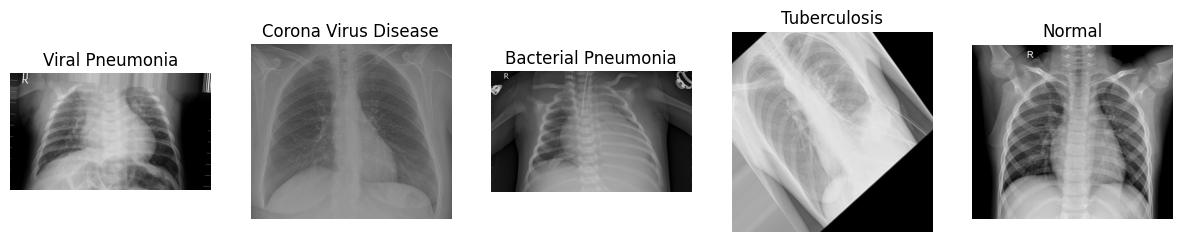

In [ ]:
# 5. Visualize a sample image per class (optional, comment out if not needed)
import os
from PIL import Image

plt.figure(figsize=(15,6))
class_dirs = [os.path.join(train_dir, cls) for cls in os.listdir(train_dir)]
for idx, class_dir in enumerate(class_dirs):
    img_file = os.listdir(class_dir)[0]
    img_path = os.path.join(class_dir, img_file)
    img = Image.open(img_path)
    plt.subplot(1, 5, idx+1)
    plt.imshow(img, cmap='gray')
    plt.title(os.path.basename(class_dir))
    plt.axis('off')
plt.show()

In [ ]:
# 6. Model: efficientnet_b0
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import torch.nn as nn

# Load EfficientNet-B0 with pretrained weights
model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
for param in model.parameters():
    param.requires_grad = False  # Freeze backbone for now

# Custom classifier head (2 layers + ReLU + Dropout)
num_classes = 5  # Your number of classes
in_features = model.classifier[1].in_features  # EfficientNet's global pool output

model.classifier = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, num_classes)
)
model = model.to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 122MB/s] 


In [ ]:
# 7. Loss, optimizer, scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

# 8. Training loop
epochs = 20
best_acc = 0.0

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
    epoch_loss = running_loss / len(train_loader.dataset)

    # Validation
    model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            val_correct += torch.sum(preds == labels).item()
            val_total += labels.size(0)
    val_acc = val_correct / val_total
    print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f} - Val Acc: {val_acc:.4f}")

    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_densenet_model.pth")

    scheduler.step()

Epoch 1/20 - Loss: 1.1343 - Val Acc: 0.7336
Epoch 2/20 - Loss: 0.6959 - Val Acc: 0.7480
Epoch 3/20 - Loss: 0.5881 - Val Acc: 0.7768
Epoch 4/20 - Loss: 0.5292 - Val Acc: 0.8021
Epoch 5/20 - Loss: 0.5222 - Val Acc: 0.7788
Epoch 6/20 - Loss: 0.4972 - Val Acc: 0.7639
Epoch 7/20 - Loss: 0.4958 - Val Acc: 0.7991
Epoch 8/20 - Loss: 0.4902 - Val Acc: 0.8100
Epoch 9/20 - Loss: 0.4936 - Val Acc: 0.8080
Epoch 10/20 - Loss: 0.4903 - Val Acc: 0.7649
Epoch 11/20 - Loss: 0.4915 - Val Acc: 0.7827
Epoch 12/20 - Loss: 0.4911 - Val Acc: 0.7639
Epoch 13/20 - Loss: 0.4943 - Val Acc: 0.8080
Epoch 14/20 - Loss: 0.4879 - Val Acc: 0.7956
Epoch 15/20 - Loss: 0.4914 - Val Acc: 0.7852
Epoch 16/20 - Loss: 0.4919 - Val Acc: 0.7847
Epoch 17/20 - Loss: 0.4961 - Val Acc: 0.7842
Epoch 18/20 - Loss: 0.4845 - Val Acc: 0.7644
Epoch 19/20 - Loss: 0.4792 - Val Acc: 0.7659
Epoch 20/20 - Loss: 0.4900 - Val Acc: 0.8090


In [ ]:
# 9. Load best model & test evaluation
model.load_state_dict(torch.load("best_densenet_model.pth"))
model.eval()
test_correct = 0
test_preds = []
test_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        test_correct += torch.sum(preds == labels).item()
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())
test_acc = test_correct / len(test_loader.dataset)
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.8198


Classification Report:
                      precision    recall  f1-score   support

 Bacterial Pneumonia       0.78      0.62      0.69       403
Corona Virus Disease       0.91      0.94      0.92       407
              Normal       0.79      0.96      0.87       404
        Tuberculosis       0.95      0.91      0.93       408
     Viral Pneumonia       0.67      0.67      0.67       403

            accuracy                           0.82      2025
           macro avg       0.82      0.82      0.82      2025
        weighted avg       0.82      0.82      0.82      2025



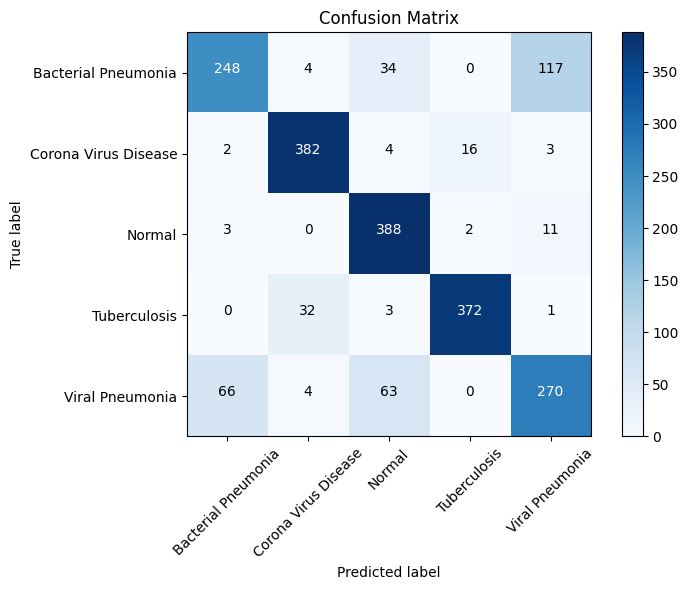

In [ ]:
# 10. Classification report & confusion matrix
print("Classification Report:")
print(classification_report(test_labels, test_preds, target_names=class_names))

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    plt.figure(figsize=(8,6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

cm = confusion_matrix(test_labels, test_preds)
plot_confusion_matrix(cm, class_names, title='Confusion Matrix')
plt.show()

In [ ]:
!cp best_densenet_model.pth /content/drive/MyDrive/


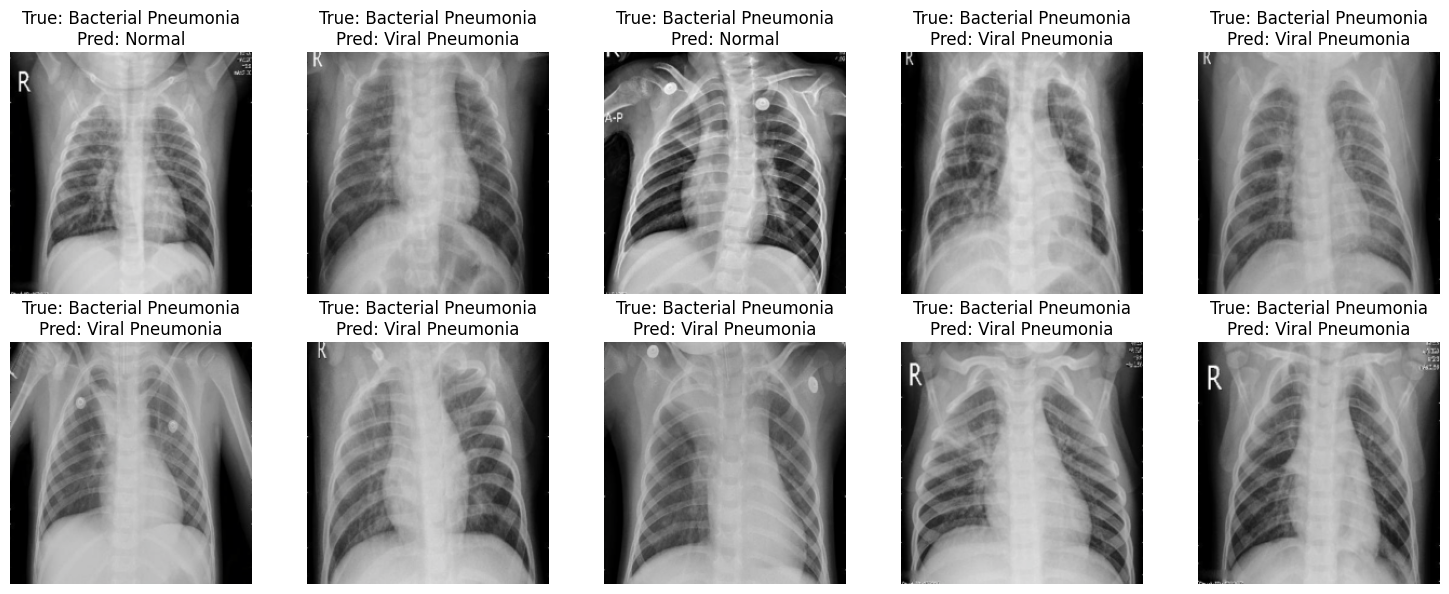

In [ ]:
import matplotlib.pyplot as plt

def show_misclassified(test_loader, model, class_names, device, n=10):
    model.eval()
    misclassified = []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            for i in range(len(labels)):
                if preds[i] != labels[i]:
                    misclassified.append((images[i].cpu(), labels[i].cpu(), preds[i].cpu()))
                if len(misclassified) >= n:
                    break
            if len(misclassified) >= n:
                break
    plt.figure(figsize=(15, 6))
    for i, (img, true, pred) in enumerate(misclassified):
        img = img.numpy().transpose((1,2,0))
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)
        plt.subplot(2, n//2, i+1)
        plt.imshow(img)
        plt.title(f"True: {class_names[true]}\nPred: {class_names[pred]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Usage:
show_misclassified(test_loader, model, class_names, device, n=10)
